# Graph Search Algorithm

### Utilities 
util.py

In [34]:
# util.py
# -------
# Licensing Information:  You are free to use or extend these projects for
# educational purposes provided that (1) you do not distribute or publish
# solutions, (2) you retain this notice, and (3) you provide clear
# attribution to UC Berkeley, including a link to http://ai.berkeley.edu.
#
# Attribution Information: The Pacman AI projects were developed at UC Berkeley.
# The core projects and autograders were primarily created by John DeNero
# (denero@cs.berkeley.edu) and Dan Klein (klein@cs.berkeley.edu).
# Student side autograding was added by Brad Miller, Nick Hay, and
# Pieter Abbeel (pabbeel@cs.berkeley.edu).


# util.py
# -------
# Licensing Information:  You are free to use or extend these projects for
# educational purposes provided that (1) you do not distribute or publish
# solutions, (2) you retain this notice, and (3) you provide clear
# attribution to UC Berkeley, including a link to http://ai.berkeley.edu.
#
# Attribution Information: The Pacman AI projects were developed at UC Berkeley.
# The core projects and autograders were primarily created by John DeNero
# (denero@cs.berkeley.edu) and Dan Klein (klein@cs.berkeley.edu).
# Student side autograding was added by Brad Miller, Nick Hay, and
# Pieter Abbeel (pabbeel@cs.berkeley.edu).


import sys
import inspect
import heapq, random

"""
 Data structures useful for implementing SearchAgents
"""


class Stack:
    "A container with a last-in-first-out (LIFO) queuing policy."

    def __init__(self):
        self.list = []

    def push(self, item):
        "Push 'item' onto the stack"
        self.list.append(item)

    def pop(self):
        "Pop the most recently pushed item from the stack"
        return self.list.pop()

    def isEmpty(self):
        "Returns true if the stack is empty"
        return len(self.list) == 0


class Queue:
    "A container with a first-in-first-out (FIFO) queuing policy."

    def __init__(self):
        self.list = []

    def enqueue(self, item):
        "Enqueue the 'item' into the queue"
        self.list.insert(0, item)

    def dequeue(self):
        """
        Dequeue the earliest enqueued item still in the queue. This
        operation removes the item from the queue.
        """
        return self.list.pop()

    def isEmpty(self):
        "Returns true if the queue is empty"
        return len(self.list) == 0


class PriorityQueue:
    """
    Implements a priority queue data structure. Each inserted item
    has a priority associated with it and the client is usually interested
    in quick retrieval of the lowest-priority item in the queue. This
    data structure allows O(1) access to the lowest-priority item.
    """

    def __init__(self):
        self.heap = []
        self.count = 0

    def insert(self, item, priority):
        entry = (priority, self.count, item)
        heapq.heappush(self.heap, entry)
        self.count += 1

    def remove(self):
        (_, _, item) = heapq.heappop(self.heap)
        return item

    def isEmpty(self):
        return len(self.heap) == 0

    def update(self, item, priority):
        # If item already in priority queue with higher priority, update its priority and rebuild the heap.
        # If item already in priority queue with equal or lower priority, do nothing.
        # If item not in priority queue, do the same thing as self.push.
        for index, (p, c, i) in enumerate(self.heap):
            if i == item:
                if p <= priority:
                    break
                del self.heap[index]
                self.heap.append((priority, c, item))
                heapq.heapify(self.heap)
                break
        else:
            self.push(item, priority)

    def show(self):
        """Returns a list of items in the heap."""
        return [
            item for priority, count, item in self.heap
        ]  # returns just the items in a list

    def __iter__(self):
        """Returns an iterator for the priority queue."""
        return iter(self.show())


"""
  Data structures and functions useful for various course projects

  The search project should not need anything below this line.
"""

'\n  Data structures and functions useful for various course projects\n\n  The search project should not need anything below this line.\n'

### Defining Graphs

In [35]:
G2 = {
    "S": [("D", 2), ("A", 3)],
    "A": [("G", 10), ("B", 5)],
    "B": [("E", 2), ("C", 1)],
    "C": [("G", 3)],
    "D": [("E", 4), ("B", 1)],
    "E": [("G", 4)],
}
G1 = {
    "S": [("A", 3), ("D", 2)],
    "A": [("B", 5), ("G", 10)],
    "B": [("C", 1), ("E", 2)],
    "C": [("B", 1)],
    "D": [("B", 1), ("E", 4)],
    "E": [("G", 4)],
}

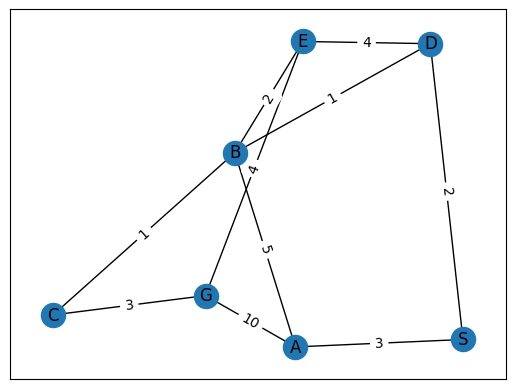

In [ ]:
import networkx as nx
import matplotlib as plt


def draw_weighted_graph(G):
    graph = nx.Graph()
    # Add nodes and weighted edges to the graph
    for node, neighbors in G.items():
        for neighbor, weight in neighbors:
            graph.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(graph)
    # Draw nodes
    nx.draw_networkx_nodes(graph, pos)
    # Draw edges with weights
    nx.draw_networkx_edges(graph, pos)
    edge_labels = nx.get_edge_attributes(graph, "weight")
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)
    # Draw node labels
    nx.draw_networkx_labels(graph, pos)
    # plt.show()


draw_weighted_graph(G2)


### BFS

In [37]:
def bfs(G, start, goal):
    closed = []
    fringe = Queue()
    fringe.enqueue(start)

    while not fringe.isEmpty():
        current = fringe.dequeue()
        print(f"\ncurrent={current}->---neighnours: ", end="")
        if current == goal:
            closed.append(goal)
            return closed
        if current not in closed:
            closed.append(current[0])
            # print(current, end=" ")
            for neighbor in G[current[0]]:
                print(neighbor, end="")
                if neighbor[0] not in closed:
                    fringe.enqueue(neighbor[0])

In [38]:
path = bfs(G1, "S", "G")
print("\nBFS path is: ", path)


current=S->---neighnours: ('A', 3)('D', 2)
current=A->---neighnours: ('B', 5)('G', 10)
current=D->---neighnours: ('B', 1)('E', 4)
current=B->---neighnours: ('C', 1)('E', 2)
current=G->---neighnours: 
BFS path is:  ['S', 'A', 'D', 'B', 'G']


### DFS

In [39]:
def dfs(G, start, goal):
    closed = []
    fringe = Stack()
    fringe.push(start)

    while not fringe.isEmpty():
        cur_node = fringe.pop()
        print(f"\ncurrent={cur_node}->---neighnours: ", end="")
        if cur_node == goal:
            closed.append(goal)
            return closed
        if cur_node not in closed:
            closed.append(cur_node[0])
            # print(cur_node, end=" ")
            for neighbor in G[cur_node[0]]:
                print(neighbor, end="")
                if neighbor[0] not in closed:
                    fringe.push(neighbor[0])

In [40]:
path = dfs(G2, "S", "G")
print("\nDFS path is: ", path)


current=S->---neighnours: ('D', 2)('A', 3)
current=A->---neighnours: ('G', 10)('B', 5)
current=B->---neighnours: ('E', 2)('C', 1)
current=C->---neighnours: ('G', 3)
current=G->---neighnours: 
DFS path is:  ['S', 'A', 'B', 'C', 'G']


### UCS

In [41]:
def ucs(G, start, goal):
    closed = []
    total_cost = 0
    fringe = PriorityQueue()
    fringe.insert(start, 0)

    while not fringe.isEmpty():
        cur_node = fringe.remove()
        print(f"current={cur_node}-> ", end="")

        if cur_node == goal:
            closed.append(goal)
            return closed, total_cost

        if cur_node not in closed:
            closed.append(cur_node)
            for neighbor, cost in G[cur_node]:
                total_cost += cost
                print(f"{neighbor}-{cost}", end=" ")
                if neighbor not in closed:
                    fringe.insert(neighbor, cost)
            print("\tfringe items", list(iter(fringe)))

In [42]:
result = ucs(G2, "S", "G")
print(f"\npath={result[0]}, cost={result[1]}")

current=S-> D-2 A-3 	fringe items ['D', 'A']
current=D-> E-4 B-1 	fringe items ['B', 'E', 'A']
current=B-> E-2 C-1 	fringe items ['C', 'E', 'A', 'E']
current=C-> G-3 	fringe items ['E', 'G', 'A', 'E']
current=E-> G-4 	fringe items ['A', 'G', 'E', 'G']
current=A-> G-10 B-5 	fringe items ['G', 'G', 'E', 'G']
current=G-> 
path=['S', 'D', 'B', 'C', 'E', 'A', 'G'], cost=35
